## Section 1: Individual Model Quality

Compares Logistic Regression baseline against the five RF benchmark models (v100–v104) by validation AUC.
These models are **never used as merge candidates**. They exist purely to show what a single well-tuned model achieves,
giving context for the merged-model AUC results in Section 3.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PATH CONFIG ────────────────────────────────────────────
BASE = r"C:\Users\User\Desktop\ICTer\WordTemplate-1"

sns.set(style="whitegrid")

# Individual model AUC: logistic baseline vs RF benchmark models (v100-v104)
# These are evaluation-only models, never used as merge candidates.

fraud_data = pd.DataFrame({
    "model": [
        "Logistic Baseline",
        "RF v100", "RF v101", "RF v102", "RF v103", "RF v104"
    ],
    "auc": [
        0.9653,
        0.9913, 0.9569, 0.9657, 0.9682, 0.9834
    ],
    "task": "Fraud"
})

churn_data = pd.DataFrame({
    "model": [
        "Logistic Baseline",
        "RF v100", "RF v101", "RF v102", "RF v103", "RF v104"
    ],
    "auc": [
        0.9924,
        0.9646, 0.9580, 0.9609, 0.9498, 0.9621
    ],
    "task": "Churn"
})

for df in [fraud_data, churn_data]:
    df["type"] = np.where(df["model"] == "Logistic Baseline", "Baseline", "Benchmark")


**Credit Card Fraud Detection: Individual Model AUC**

c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDty

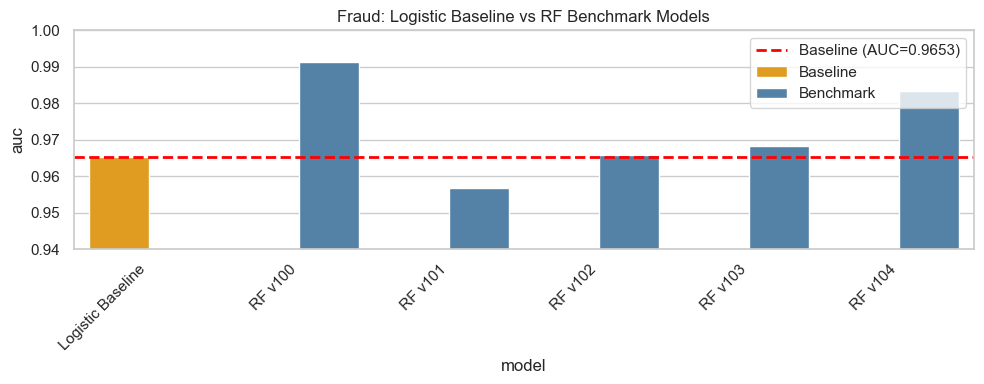

In [35]:
baseline_auc_fraud = 0.9653

plt.figure(figsize=(10, 4))
palette = {"Baseline": "orange", "Benchmark": "steelblue"}
sns.barplot(data=fraud_data, x="model", y="auc", hue="type", palette=palette)
plt.axhline(y=baseline_auc_fraud, color="red", linestyle="--", linewidth=2,
            label=f"Baseline (AUC={baseline_auc_fraud:.4f})")
plt.title("Fraud: Logistic Baseline vs RF Benchmark Models")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.94, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


**Telco Customer Churn: Individual Model AUC**

c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDty

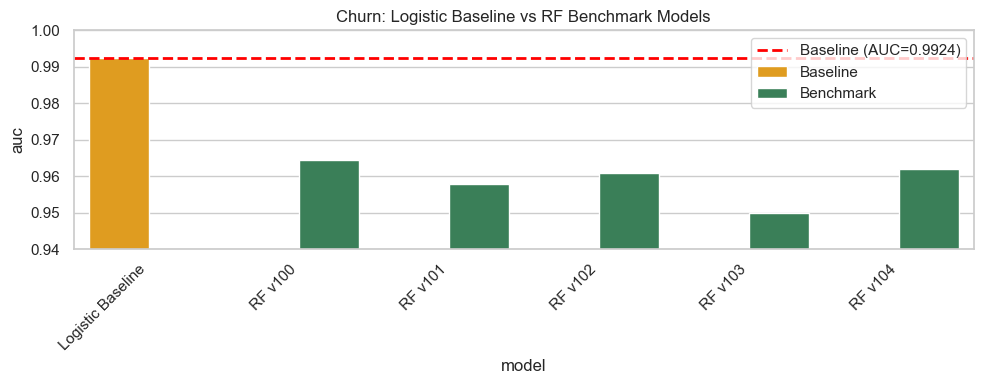

In [36]:
baseline_auc_churn = 0.9924

plt.figure(figsize=(10, 4))
palette = {"Baseline": "orange", "Benchmark": "seagreen"}
sns.barplot(data=churn_data, x="model", y="auc", hue="type", palette=palette)
plt.axhline(y=baseline_auc_churn, color="red", linestyle="--", linewidth=2,
            label=f"Baseline (AUC={baseline_auc_churn:.4f})")
plt.title("Churn: Logistic Baseline vs RF Benchmark Models")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.94, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


## Section 2: ECCM Compatibility Scoring Results

Loads the benchmark CSV produced by `run_benchmarks.py` and sets up shared
configuration used by all charts in Sections 4–7.

**Methods compared:**

| Method | What it is |
|--------|------------|
| Random | Uniformly random scores - theoretical floor |
| PSC-only | Cosine similarity of feature importances (ECCM sub-metric) |
| FSC-only | Pearson correlation of predict_proba outputs (ECCM sub-metric) |
| AUC-Max | Score pairs by max(AUC_A, AUC_B) - naive practitioner heuristic |
| **ECCM (full)** | Weighted composite of PSC + FSC + RSC (the proposed method )|

**Metrics explained:**

| Metric | What it measures |
|--------|------------------|
| Spearman r | Rank correlation with actual AUC improvement (primary metric) |
| p-val | Statistical significance - want < 0.05 |
| AUC-ROC | Can the score separate successful merges from failures? |
| Prec@10 | Of the top-10 ranked pairs, what fraction actually improved AUC? |
| Lift@10 | Prec@10 / base success rate - values > 1.0 beat random selection |


In [ ]:
# Loading the benchmark summary produced by run_benchmarks.py

fraud_df    = pd.read_csv(f"{BASE}results/benchmarks/fraud.csv")
churn_df    = pd.read_csv(f"{BASE}results/benchmarks/churn.csv")
summary     = pd.read_csv(f"{BASE}results/benchmarks/summary.csv")

# Consistent method order for all charts
METHOD_ORDER = ["Random", "PSC-only", "FSC-only", "AUC-Max", "CMA-ES (M2N2)", "ECCM (full)"]

# Colour palette -- ECCM highlighted in red, baselines in muted tones
COLORS = {
    "Random":      "#95a5a6",
    "PSC-only":    "#3498db",
    "FSC-only":    "#2ecc71",
    "AUC-Max":     "#e67e22",
    "CMA-ES (M2N2)": "#9b59b6",
    "ECCM (full)": "#e74c3c",
}

print("Benchmark summary loaded successfully.")
print(f"Tasks: {summary['task'].unique().tolist()}")
print(f"Methods: {summary['method'].unique().tolist()}")


Benchmark summary loaded successfully.
Tasks: ['fraud', 'churn']
Methods: ['Random', 'PSC-only', 'FSC-only', 'AUC-Max', 'ECCM (full)', 'CMA-ES (M2N2)']


## Section 3: Merged Model AUC vs Individual Models

Shows how the best ECCM-guided merged pair for each task compares to the
benchmark RF models from Section 1. This answers the core question: **does merging actually help?**

Fill in the four AUC values from your result CSVs using the instructions in the first cell below.
Once filled in, run the second cell to produce the comparison chart.

In [ ]:
# Best fixed-ratio merge AUC:
#   Open results/merges/{task}/merge_results_new_eccm.csv
#   highest value in the auc_merged column.
#
# Best CMA-ES merge AUC:
#   Open results/merges/{task}/m2n2_results.csv
#   highest value in the opt_best_auc column.


fraud_fixed = pd.read_csv(f"{BASE}results/merges/fraud/merge_results_new_eccm.csv")
fraud_m2n2  = pd.read_csv(f"{BASE}results/merges/fraud/m2n2results.csv")
churn_fixed = pd.read_csv(f"{BASE}results/merges/churn/merge_results_new_eccm.csv")
churn_m2n2  = pd.read_csv(f"{BASE}results/merges/churn/m2n2results.csv")

fraud_fixed_auc = fraud_fixed["auc_merged"].max()
fraud_cmaes_auc = fraud_m2n2["opt_best_auc"].max()
churn_fixed_auc = churn_fixed["auc_merged"].max()
churn_cmaes_auc = churn_m2n2["opt_best_auc"].max()

print(f"Fraud  — Fixed best: {fraud_fixed_auc:.4f}  |  CMA-ES best: {fraud_cmaes_auc:.4f}")
print(f"Churn  — Fixed best: {churn_fixed_auc:.4f}  |  CMA-ES best: {churn_cmaes_auc:.4f}")


Fraud  — Fixed best: 1.0000  |  CMA-ES best: 1.0000
Churn  — Fixed best: 0.9882  |  CMA-ES best: 0.9886


c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDty

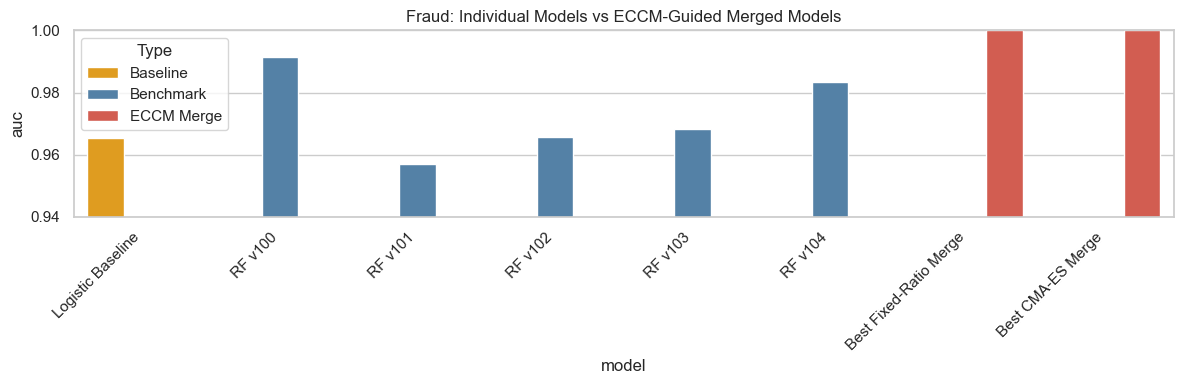

c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\User\Mergence-ECCM\.venv\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDty

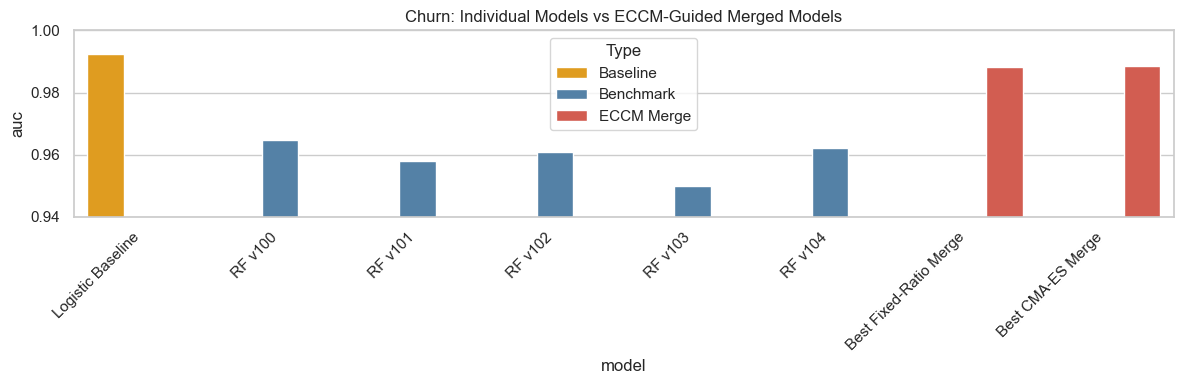

In [39]:
if None in [fraud_fixed_auc, fraud_cmaes_auc, churn_fixed_auc, churn_cmaes_auc]:
    print("Fill in the merged AUC values in the cell above first, then re-run.")
else:
    merged_data = {
        "Fraud": {
            "Best Fixed-Ratio Merge": fraud_fixed_auc,
            "Best CMA-ES Merge":      fraud_cmaes_auc,
        },
        "Churn": {
            "Best Fixed-Ratio Merge": churn_fixed_auc,
            "Best CMA-ES Merge":      churn_cmaes_auc,
        },
    }

    for task, ind_df, ylim_low in [("Fraud", fraud_data, 0.94), ("Churn", churn_data, 0.94)]:
        merge_rows = pd.DataFrame([
            {"model": name, "auc": auc, "type": "ECCM Merge"}
            for name, auc in merged_data[task].items()
        ])
        combined = pd.concat(
            [ind_df[["model", "auc", "type"]], merge_rows],
            ignore_index=True
        )
        palette = {"Baseline": "orange", "Benchmark": "steelblue", "ECCM Merge": "#e74c3c"}

        plt.figure(figsize=(12, 4))
        sns.barplot(data=combined, x="model", y="auc", hue="type", palette=palette)
        plt.title(f"{task}: Individual Models vs ECCM-Guided Merged Models")
        plt.xticks(rotation=45, ha="right")
        plt.ylim(ylim_low, 1.0)
        plt.legend(title="Type")
        plt.tight_layout()
        plt.savefig(f"{BASE}\\results\\benchmarks\\merged_vs_individual_{task.lower()}.png",
            dpi=150, bbox_inches="tight")
        plt.show()


## Section 4: Spearman r: Rank Correlation with AUC Improvement

**Primary metric.** Spearman r measures how well each scoring method ranks
model pairs by their actual AUC improvement. A value close to 1.0 means
the method perfectly ranks good pairs above bad ones.

An asterisk (*) means the correlation is statistically significant (p < 0.05).
Bars below zero mean the method is inversely correlated with improvement.

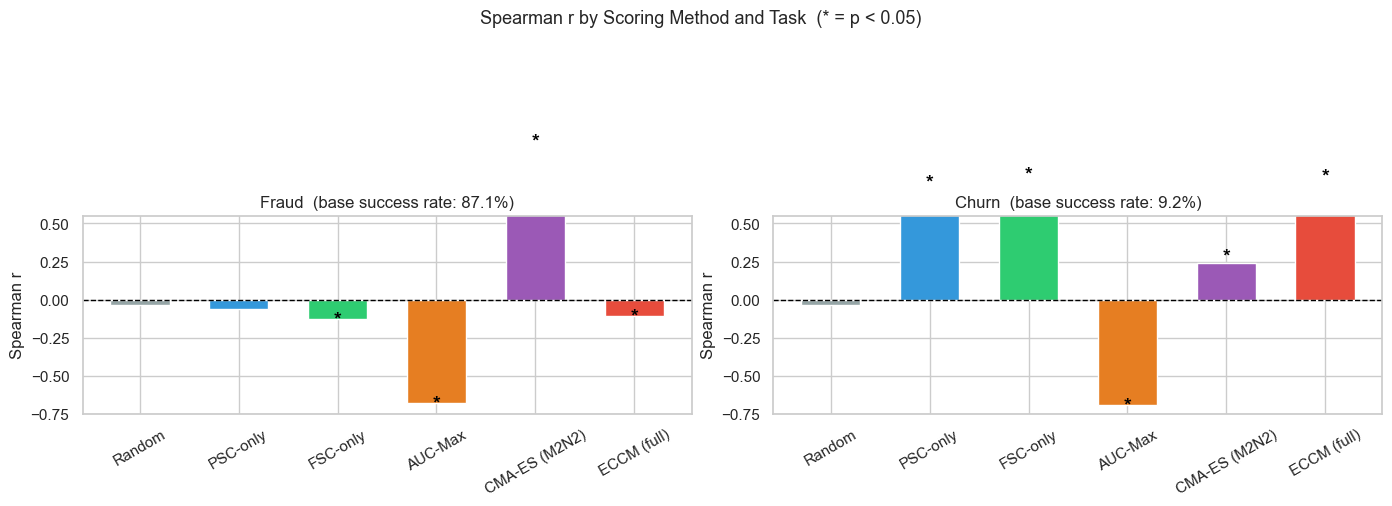

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, ["fraud", "churn"]):
    t = summary[summary["task"] == task].copy()
    t["method"] = pd.Categorical(t["method"], categories=METHOD_ORDER, ordered=True)
    t = t.sort_values("method")

    bar_colors = [COLORS[m] for m in t["method"]]
    bars = ax.bar(t["method"], t["spearman_r"], color=bar_colors, edgecolor="white", width=0.6)

    # Zero line
    ax.axhline(0, color="black", linewidth=1, linestyle="--")

    # Mark statistically significant bars with *
    for bar, (_, row) in zip(bars, t.iterrows()):
        if row["spearman_p"] < 0.05:
            ypos = row["spearman_r"] + (0.01 if row["spearman_r"] >= 0 else -0.035)
            ax.text(bar.get_x() + bar.get_width() / 2, ypos, "*",
                    ha="center", fontsize=14, fontweight="bold", color="black")

    base_rate = t["base_success_rate"].iloc[0]
    ax.set_title(f"{task.capitalize()}  (base success rate: {base_rate:.1%})")
    ax.set_ylabel("Spearman r")
    ax.set_ylim(-0.75, 0.55)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Spearman r by Scoring Method and Task  (* = p < 0.05)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE}\\results\\benchmarks\\spearman_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()


## Section 5: AUC-ROC: Binary Separation of Success vs Failure

AUC-ROC treats the task as binary classification: can the score separate
pairs where merging improved AUC (success=1) from pairs where it did not (success=0)?

- 0.5 = random (dashed line) - the method provides no useful signal.
- \> 0.5 = better than random.
- < 0.5 = worse than random (inverted signal).

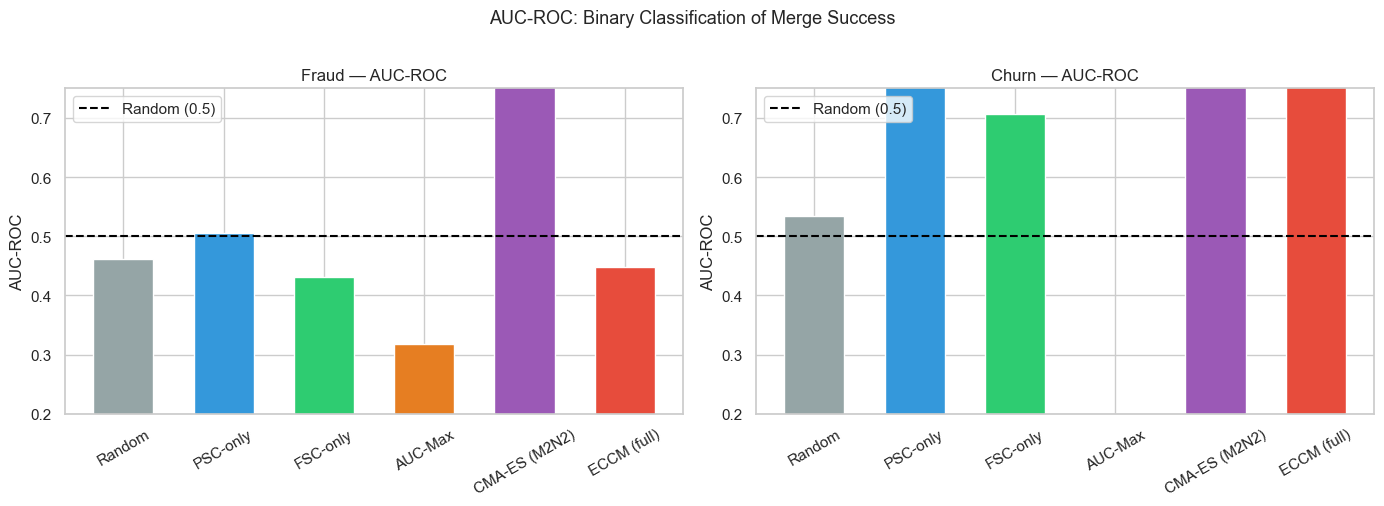

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, ["fraud", "churn"]):
    t = summary[summary["task"] == task].copy()
    t["method"] = pd.Categorical(t["method"], categories=METHOD_ORDER, ordered=True)
    t = t.sort_values("method")

    bar_colors = [COLORS[m] for m in t["method"]]
    ax.bar(t["method"], t["auc_roc"], color=bar_colors, edgecolor="white", width=0.6)
    ax.axhline(0.5, color="black", linewidth=1.5, linestyle="--", label="Random (0.5)")

    ax.set_title(f"{task.capitalize()} — AUC-ROC")
    ax.set_ylabel("AUC-ROC")
    ax.set_ylim(0.2, 0.75)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

fig.suptitle("AUC-ROC: Binary Classification of Merge Success", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE}\\results\\benchmarks\\auc_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 6: Precision@K and Lift@K

**Precision@K**: of the top-K pairs ranked by each method, what fraction actually improved AUC?

**Lift@K**: Precision@K divided by the base success rate.
- Lift = 1.0 → same as picking pairs at random
- Lift > 1.0 → method beats random at selecting good pairs
- Lift < 1.0 → method is worse than random

K=10 is the most practically relevant cutoff (if you could only attempt 10 merges,
how many would ECCM help you get right?)

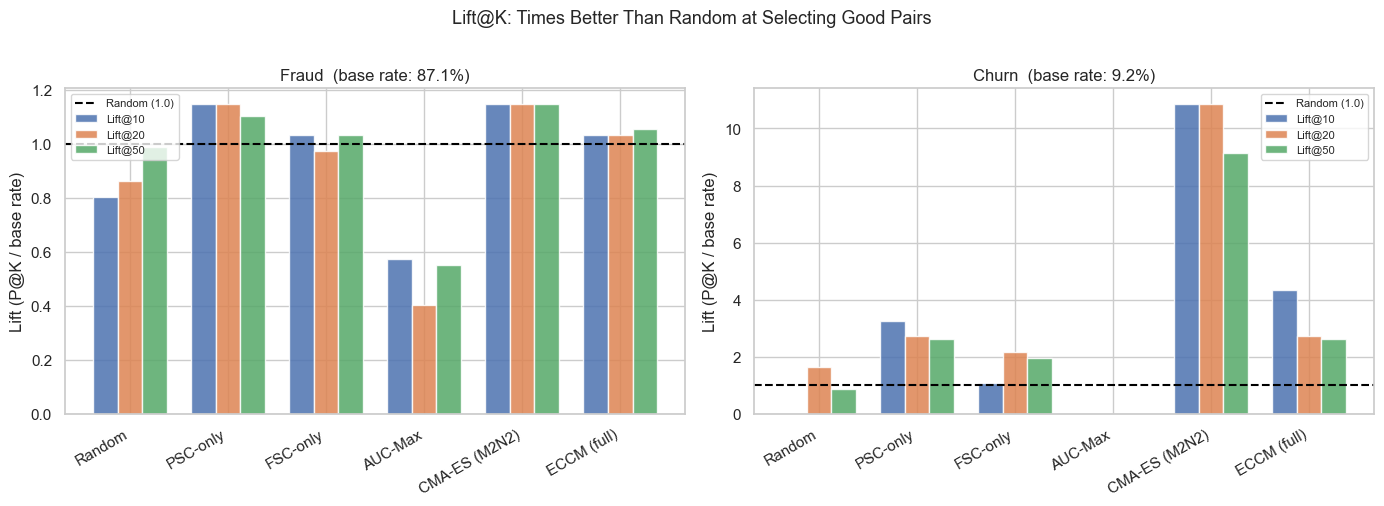

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, ["fraud", "churn"]):
    t = summary[summary["task"] == task].copy()
    t["method"] = pd.Categorical(t["method"], categories=METHOD_ORDER, ordered=True)
    t = t.sort_values("method")

    k_cols   = ["lift@10", "lift@20", "lift@50"]
    k_labels = ["Lift@10", "Lift@20", "Lift@50"]
    x        = np.arange(len(t))
    width    = 0.25

    for i, (col, label) in enumerate(zip(k_cols, k_labels)):
        ax.bar(x + i * width, t[col], width, label=label, alpha=0.85)

    ax.axhline(1.0, color="black", linewidth=1.5, linestyle="--", label="Random (1.0)")
    ax.set_xticks(x + width)
    ax.set_xticklabels(t["method"], rotation=30, ha="right")
    base_rate = t["base_success_rate"].iloc[0]
    ax.set_title(f"{task.capitalize()}  (base rate: {base_rate:.1%})")
    ax.set_ylabel("Lift (P@K / base rate)")
    ax.legend(fontsize=8)

fig.suptitle("Lift@K: Times Better Than Random at Selecting Good Pairs", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE}\\results\\benchmarks\\lift_k_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 7: Full Summary Table

All metrics for all methods in one table per task.
The ECCM (full) row is the proposed method. Everything else is a baseline.

In [43]:
cols = [
    "method", "spearman_r", "spearman_p", "auc_roc",
    "prec@10", "prec@20", "prec@50",
    "lift@10", "lift@20", "lift@50",
    "base_success_rate"
]

for task in ["fraud", "churn"]:
    t = summary[summary["task"] == task].copy()
    t["method"] = pd.Categorical(t["method"], categories=METHOD_ORDER, ordered=True)
    t = t.sort_values("method")[cols]

    print(f"\n{'='*90}")
    print(f"  {task.upper()}  —  base success rate: {t['base_success_rate'].iloc[0]:.1%}")
    print(f"{'='*90}")
    print(t.to_string(index=False))
    print()
    print("  * Spearman p < 0.05 = statistically significant rank correlation")
    print("  * Lift > 1.0 = method beats random pair selection at that cutoff")



  FRAUD  —  base success rate: 87.1%
       method  spearman_r  spearman_p  auc_roc  prec@10  prec@20  prec@50  lift@10  lift@20  lift@50  base_success_rate
       Random     -0.0382    0.338067   0.4611      0.7     0.75     0.86    0.803    0.861    0.987             0.8714
     PSC-only     -0.0636    0.110947   0.5049      1.0     1.00     0.96    1.148    1.148    1.102             0.8714
     FSC-only     -0.1283    0.001252   0.4314      0.9     0.85     0.90    1.033    0.975    1.033             0.8714
      AUC-Max     -0.6813    0.000000   0.3188      0.5     0.35     0.48    0.574    0.402    0.551             0.8714
CMA-ES (M2N2)      0.9919    0.000000   0.9852      1.0     1.00     1.00    1.148    1.148    1.148             0.8714
  ECCM (full)     -0.1079    0.006721   0.4475      0.9     0.90     0.92    1.033    1.033    1.056             0.8714

  * Spearman p < 0.05 = statistically significant rank correlation
  * Lift > 1.0 = method beats random pair selection at

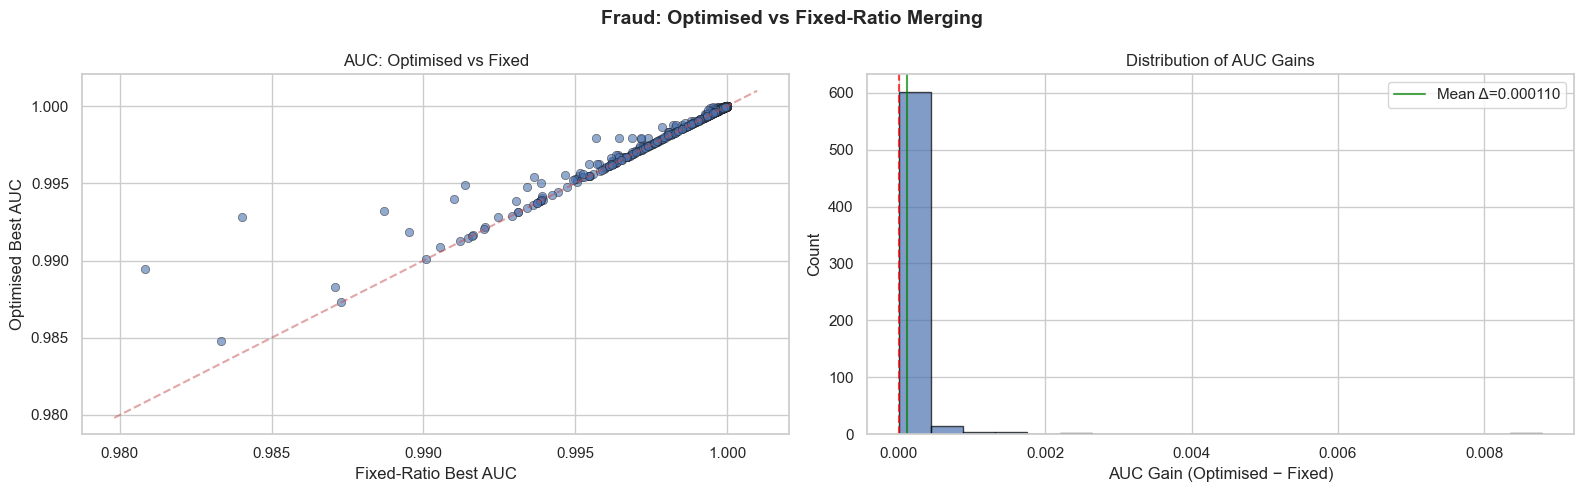

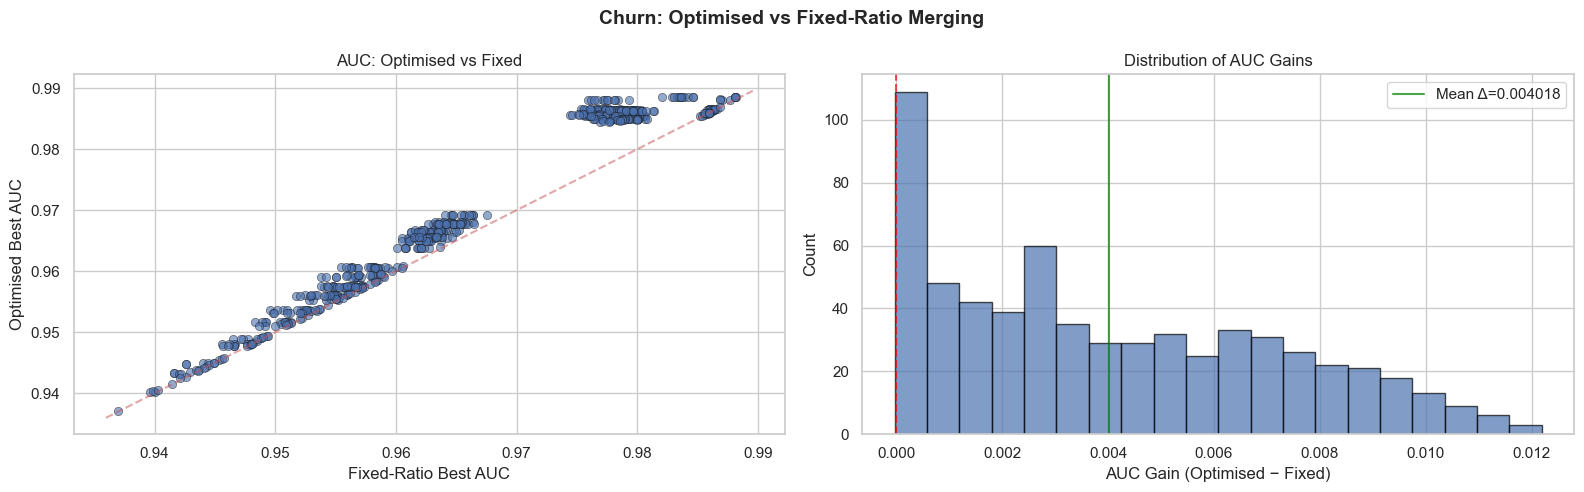

In [44]:
def plot_m2n2_comparison(results_csv: str, task_name: str):
    df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{task_name}: Optimised vs Fixed-Ratio Merging",
                 fontsize=14, fontweight="bold")

    # Left: scatter opt vs fixed AUC
    ax = axes[0]
    ax.scatter(df["fixed_best_auc"], df["opt_best_auc"],
               alpha=0.6, edgecolors="k", linewidth=0.5)
    lo = min(df["fixed_best_auc"].min(), df["opt_best_auc"].min()) - 0.001
    hi = max(df["fixed_best_auc"].max(), df["opt_best_auc"].max()) + 0.001
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.5)
    ax.set_xlabel("Fixed-Ratio Best AUC")
    ax.set_ylabel("Optimised Best AUC")
    ax.set_title("AUC: Optimised vs Fixed")

    # Right: distribution of delta
    ax = axes[1]
    delta = df["opt_vs_fixed"]
    ax.hist(delta, bins=20, edgecolor="black", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.axvline(delta.mean(), color="green", linestyle="-",
               alpha=0.7, label=f"Mean Δ={delta.mean():.6f}")
    ax.set_xlabel("AUC Gain (Optimised − Fixed)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of AUC Gains")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_m2n2_comparison(
    f"{BASE}/results/merges/fraud/m2n2_results.csv", "Fraud")
plot_m2n2_comparison(
    f"{BASE}/results/merges/churn/m2n2_results.csv", "Churn")